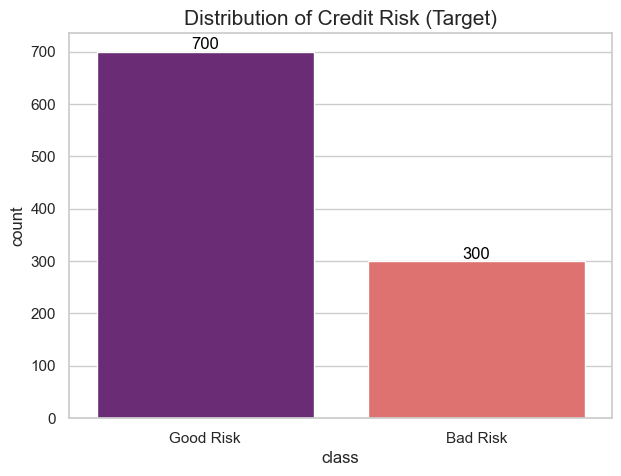

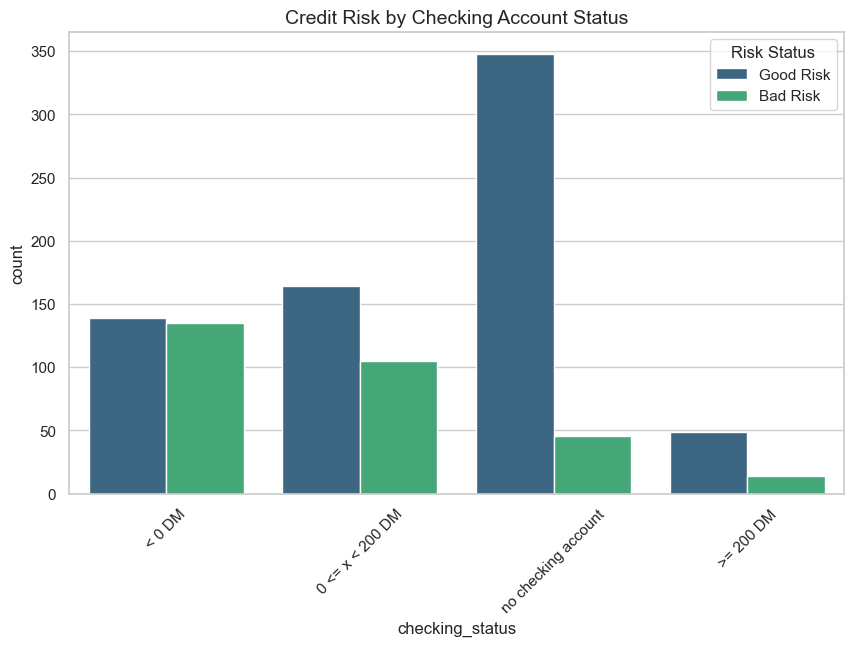

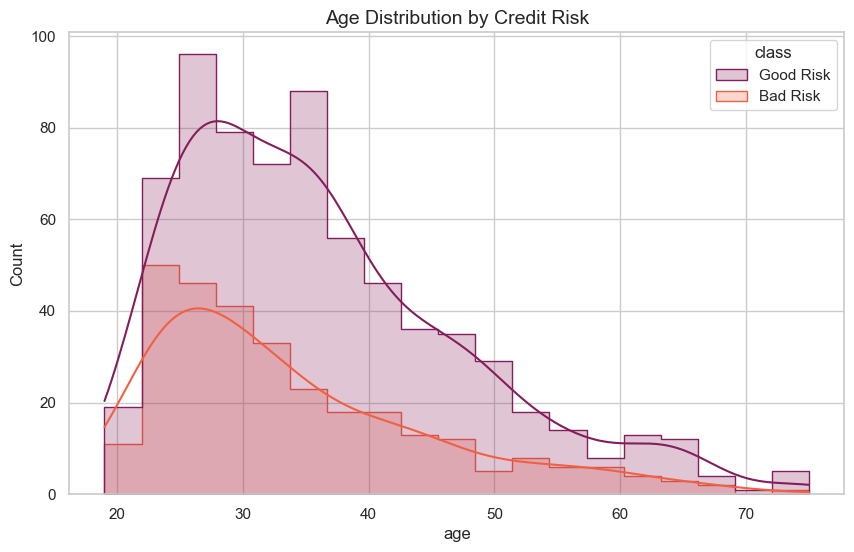

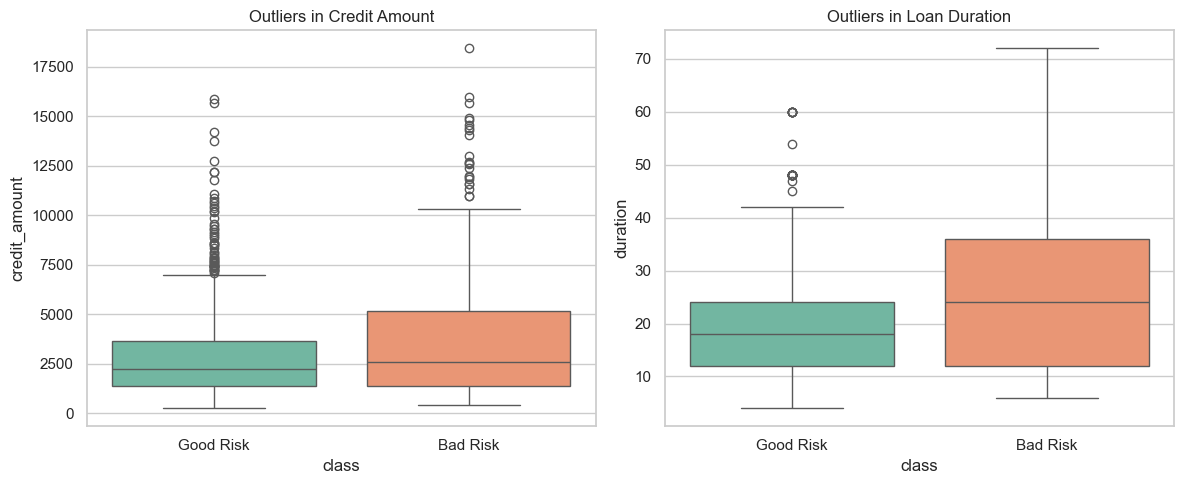

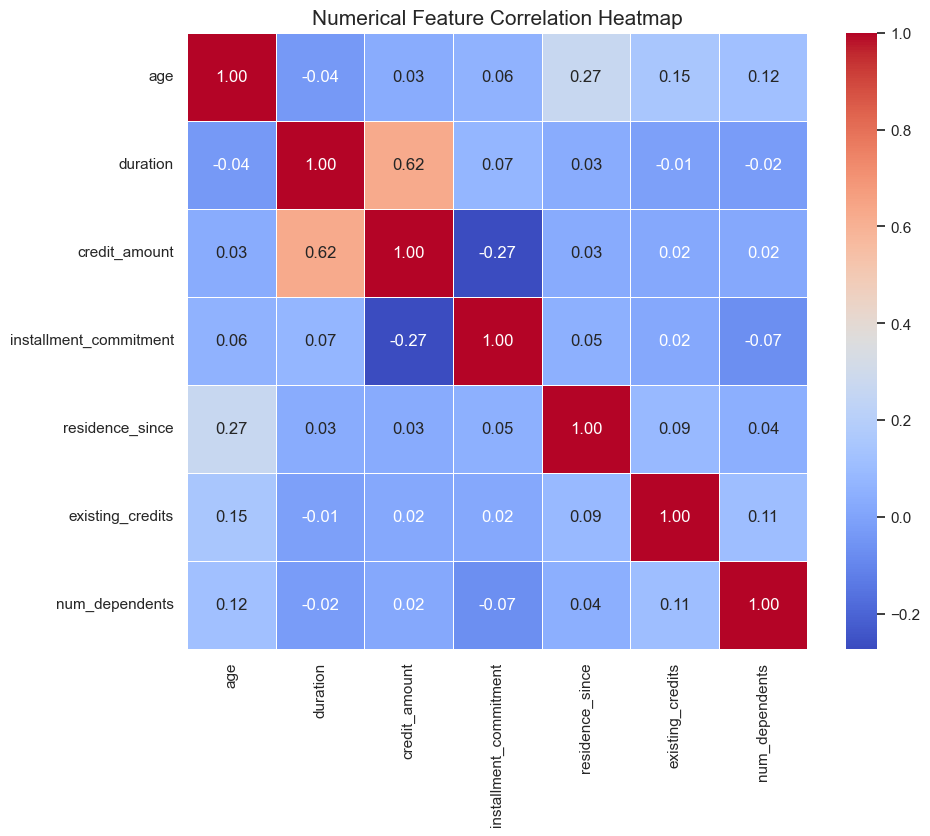

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the mapped data
df = pd.read_csv('../data/german_credit_mapped.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 2. Visualize Target Variable (The "Imbalance" Check)
plt.figure(figsize=(7, 5))

# FIX: Added hue='class' and legend=False to satisfy Seaborn v0.14+
ax = sns.countplot(x='class', hue='class', data=df, palette='magma', legend=False)

plt.title('Distribution of Credit Risk (Target)', fontsize=15)

# OPTIONAL: Add actual counts on top of bars for better readability
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# 3. Financial Health vs. Risk
# Let's see how checking account status influences the outcome
plt.figure(figsize=(10, 6))
sns.countplot(x='checking_status', hue='class', data=df, palette='viridis')
plt.title('Credit Risk by Checking Account Status', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Risk Status')
plt.show()

# 4. Age Distribution (The "Demographic" Check)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='class', kde=True, element="step", palette='rocket')
plt.title('Age Distribution by Credit Risk', fontsize=14)
plt.show()

# Check for Outliers in Credit Amount and Duration
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y='credit_amount', hue='class', x='class', data=df, palette='Set2', legend=False)
plt.title('Outliers in Credit Amount')

plt.subplot(1, 2, 2)
sns.boxplot(y='duration', hue='class', x='class', data=df, palette='Set2', legend=False)
plt.title('Outliers in Loan Duration')

plt.tight_layout()
plt.show()

# 6. Feature Correlation (Mathematical Relationships)
plt.figure(figsize=(10, 8))

# We only correlate numerical columns (Age, Duration, Amount)
numerical_cols = ['age', 'duration', 'credit_amount', 'installment_commitment', 'residence_since', 'existing_credits', 'num_dependents']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap', fontsize=15)
plt.show()